In [1]:
import numpy as np
import matplotlib.pyplot as plt
 
# Fix the seed so that the same points are generated on every run
np.random.seed(0)
 
# N points with 2 coordinates each; values are uniform in [0, 1)
N, K = 10, 2
X = np.random.rand(N, 2)
 
print("Generated points:")
print(X)
print("Shape of X:", X.shape)


Generated points:
[[0.5488135  0.71518937]
 [0.60276338 0.54488318]
 [0.4236548  0.64589411]
 [0.43758721 0.891773  ]
 [0.96366276 0.38344152]
 [0.79172504 0.52889492]
 [0.56804456 0.92559664]
 [0.07103606 0.0871293 ]
 [0.0202184  0.83261985]
 [0.77815675 0.87001215]]
Shape of X: (10, 2)


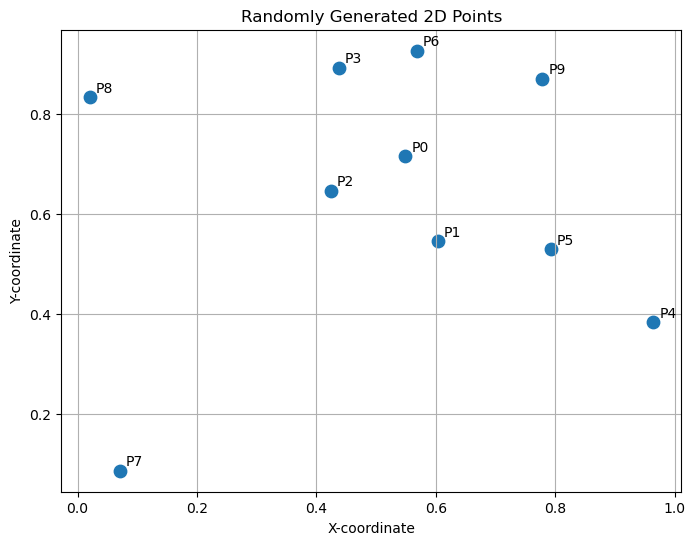

In [3]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80, color="tab:blue")
 
# Label every point with its index
for i, (px, py) in enumerate(X):
    plt.text(px + 0.01, py + 0.01, f"P{i}")
 
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("Randomly Generated 2D Points")
plt.grid(True)
plt.show()


In [5]:
# Pairwise squared Euclidean distances in a single line (no loops)
D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=2)
 
print("Shape of D2:", D2.shape)
print(np.round(D2, 3))


Shape of D2: (10, 10)
[[0.    0.032 0.02  0.044 0.282 0.094 0.045 0.623 0.293 0.077]
 [0.032 0.    0.042 0.148 0.156 0.036 0.146 0.492 0.422 0.136]
 [0.02  0.042 0.    0.061 0.36  0.149 0.099 0.437 0.198 0.176]
 [0.044 0.148 0.061 0.    0.535 0.257 0.018 0.782 0.178 0.116]
 [0.282 0.156 0.36  0.535 0.    0.051 0.45  0.885 1.092 0.271]
 [0.094 0.036 0.149 0.257 0.051 0.    0.207 0.715 0.687 0.117]
 [0.045 0.146 0.099 0.018 0.45  0.207 0.    0.95  0.309 0.047]
 [0.623 0.492 0.437 0.782 0.885 0.715 0.95  0.    0.558 1.113]
 [0.293 0.422 0.198 0.178 1.092 0.687 0.309 0.558 0.    0.576]
 [0.077 0.136 0.176 0.116 0.271 0.117 0.047 1.113 0.576 0.   ]]


In [7]:
# Step (a): coordinate differences for every pair of points
coordinate_diff = X[:, np.newaxis, :] - X[np.newaxis, :, :]
print("(a) Coordinate differences  :", coordinate_diff.shape)
 
# Step (b): square every difference
squared_diff = coordinate_diff ** 2
print("(b) Squared differences     :", squared_diff.shape)
 
# Step (c): add the squared x and y differences
summed_squared = np.sum(squared_diff, axis=2)
print("(c) Summed squared distances:", summed_squared.shape)
 
# The three-step result must agree with the single-line result
print("Same as single-line D2?", np.allclose(summed_squared, D2))


(a) Coordinate differences  : (10, 10, 2)
(b) Squared differences     : (10, 10, 2)
(c) Summed squared distances: (10, 10)
Same as single-line D2? True


In [9]:
# Extract the diagonal of the distance matrix
diagonal = np.diag(D2)
print("Diagonal of the distance matrix:")
print(diagonal)
 
# Check that every diagonal entry is zero
print("Are all diagonal values zero?", np.allclose(diagonal, 0))


Diagonal of the distance matrix:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Are all diagonal values zero? True


In [11]:
# Indices that sort each row of D2 by increasing distance
neighbor_order = np.argsort(D2, axis=1)
print("Neighbor ordering for each point:")
print(neighbor_order)
 
# The first column should be 0, 1, 2, ..., 9
print("First column:")
print(neighbor_order[:, 0])


Neighbor ordering for each point:
[[0 2 1 3 6 9 5 4 8 7]
 [1 0 5 2 9 6 3 4 8 7]
 [2 0 1 3 6 5 9 8 4 7]
 [3 6 0 2 9 1 8 5 4 7]
 [4 5 1 9 0 2 6 3 7 8]
 [5 1 4 0 9 2 6 3 8 7]
 [6 3 0 9 2 1 5 8 4 7]
 [7 2 1 8 0 5 3 4 6 9]
 [8 3 2 0 6 1 7 9 5 4]
 [9 6 0 3 5 1 2 4 8 7]]
First column:
[0 1 2 3 4 5 6 7 8 9]


In [13]:
# Skip column 0 (the point itself) and keep the next K columns
nearest_using_argsort = neighbor_order[:, 1:K + 1]
print("Two nearest neighbors using argsort:")
print(nearest_using_argsort)


Two nearest neighbors using argsort:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]


In [15]:
# Indices of the K+1 smallest distances in every row (not sorted)
candidate_indices = np.argpartition(D2, K, axis=1)[:, :K + 1]
print("K+1 candidate indices:")
print(candidate_indices)
 
# Sort only these K+1 candidates according to their distances
candidate_dist = np.take_along_axis(D2, candidate_indices, axis=1)
local_order = np.argsort(candidate_dist, axis=1)
sorted_candidates = np.take_along_axis(candidate_indices,
                                      local_order, axis=1)
 
# Drop the point itself (first column) to get the K nearest neighbours
nearest_using_partition = sorted_candidates[:, 1:K + 1]
print("Two nearest neighbors using argpartition:")
print(nearest_using_partition)
 
# Both methods must give the same answer
print("Same as argsort result?",
      np.array_equal(nearest_using_partition, nearest_using_argsort))


K+1 candidate indices:
[[0 2 1]
 [1 0 5]
 [2 0 1]
 [3 6 0]
 [4 5 1]
 [5 1 4]
 [6 3 0]
 [7 2 1]
 [8 3 2]
 [9 6 0]]
Two nearest neighbors using argpartition:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Same as argsort result? True


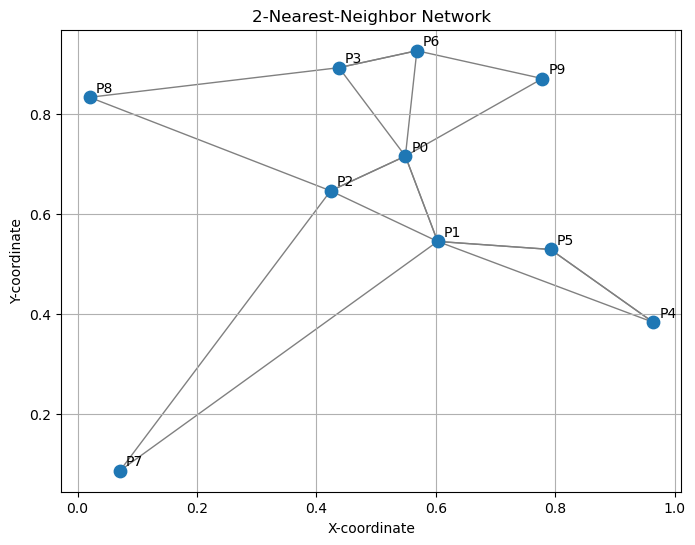

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=80, color="tab:blue", zorder=3)
 
# Label every point with its index
for i, (px, py) in enumerate(X):
    plt.text(px + 0.01, py + 0.01, f"P{i}", zorder=4)
 
# Draw a line from every point to each of its K nearest neighbours
for i in range(N):
    for j in nearest_using_partition[i]:
        plt.plot([X[i, 0], X[j, 0]], [X[i, 1], X[j, 1]],
                 color="gray", linewidth=1, zorder=1)
 
plt.xlabel("X-coordinate")
plt.ylabel("Y-coordinate")
plt.title("2-Nearest-Neighbor Network")
plt.grid(True)
plt.show()


In [19]:
def loop_neighbours(X, K=2):
    """K nearest neighbours of every point, one point at a time."""
    N = X.shape[0]
    neighbours = np.empty((N, K), dtype=int)
 
    for i in range(N):                # process one point at a time
        distances = np.empty(N)
        for j in range(N):            # distance from point i to point j
            diff = X[i] - X[j]
            distances[j] = np.dot(diff, diff)
 
        order = np.argsort(distances) # sort distances of this point
        neighbours[i] = order[1:K + 1]  # skip the point itself
 
    return neighbours


In [21]:
def vectorised_neighbours(X, K=2):
    """K nearest neighbours of every point using broadcasting."""
    # All pairwise squared distances at once (any number of dimensions)
    D2 = np.sum((X[:, np.newaxis, :] - X[np.newaxis, :, :]) ** 2, axis=-1)
 
    # K+1 smallest distances of every row (not sorted)
    candidates = np.argpartition(D2, K, axis=1)[:, :K + 1]
 
    # Order the candidates by distance and drop the point itself
    cand_dist = np.take_along_axis(D2, candidates, axis=1)
    order = np.argsort(cand_dist, axis=1)
    sorted_cand = np.take_along_axis(candidates, order, axis=1)
    return sorted_cand[:, 1:K + 1]


In [23]:
loop_result = loop_neighbours(X, K)
vec_result = vectorised_neighbours(X, K)
 
print("Vectorized result:")
print(vec_result)
print("Loop-based result:")
print(loop_result)
print("Are both results identical?",
      np.array_equal(loop_result, vec_result))


Vectorized result:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Loop-based result:
[[2 1]
 [0 5]
 [0 1]
 [6 0]
 [5 1]
 [1 4]
 [3 0]
 [2 1]
 [3 2]
 [6 0]]
Are both results identical? True


In [25]:
def make_points(n):
    np.random.seed(0)
    return np.random.rand(n, 2)
 
# ---------- N = 100 ----------
X100 = make_points(100)
%timeit vectorised_neighbours(X100, K)
%timeit loop_neighbours(X100, K)
 
# ---------- N = 1,000 ----------
X1000 = make_points(1000)
%timeit vectorised_neighbours(X1000, K)
%timeit loop_neighbours(X1000, K)
 
# ---------- N = 5,000 ----------
X5000 = make_points(5000)
%timeit vectorised_neighbours(X5000, K)
# The loop-based run takes minutes, so it is timed once only
%timeit -r 1 -n 1 loop_neighbours(X5000, K)


216 μs ± 17.2 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
13.2 ms ± 1.76 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)
32.8 ms ± 4.51 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.18 s ± 29.1 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
696 ms ± 56.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
35.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [27]:
from sklearn.neighbors import KDTree
 
# Dataset with N = 1,000 points (same generator as before)
X1000 = make_points(1000)
 
def kdtree_neighbours(X, K=2):
    tree = KDTree(X)                    # build the tree: O(N log N)
    dist, idx = tree.query(X, k=K + 1)  # K+1 neighbours per point
    return idx[:, 1:]                   # drop the point itself
 
numpy_result = vectorised_neighbours(X1000, K)
tree_result = kdtree_neighbours(X1000, K)
 
# Do both methods find the same neighbours?
print("Are both results identical?",
      np.array_equal(numpy_result, tree_result))
 
# Running times
%timeit vectorised_neighbours(X1000, K)
%timeit kdtree_neighbours(X1000, K)


Are both results identical? True
27 ms ± 2.25 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)
1.12 ms ± 81.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
